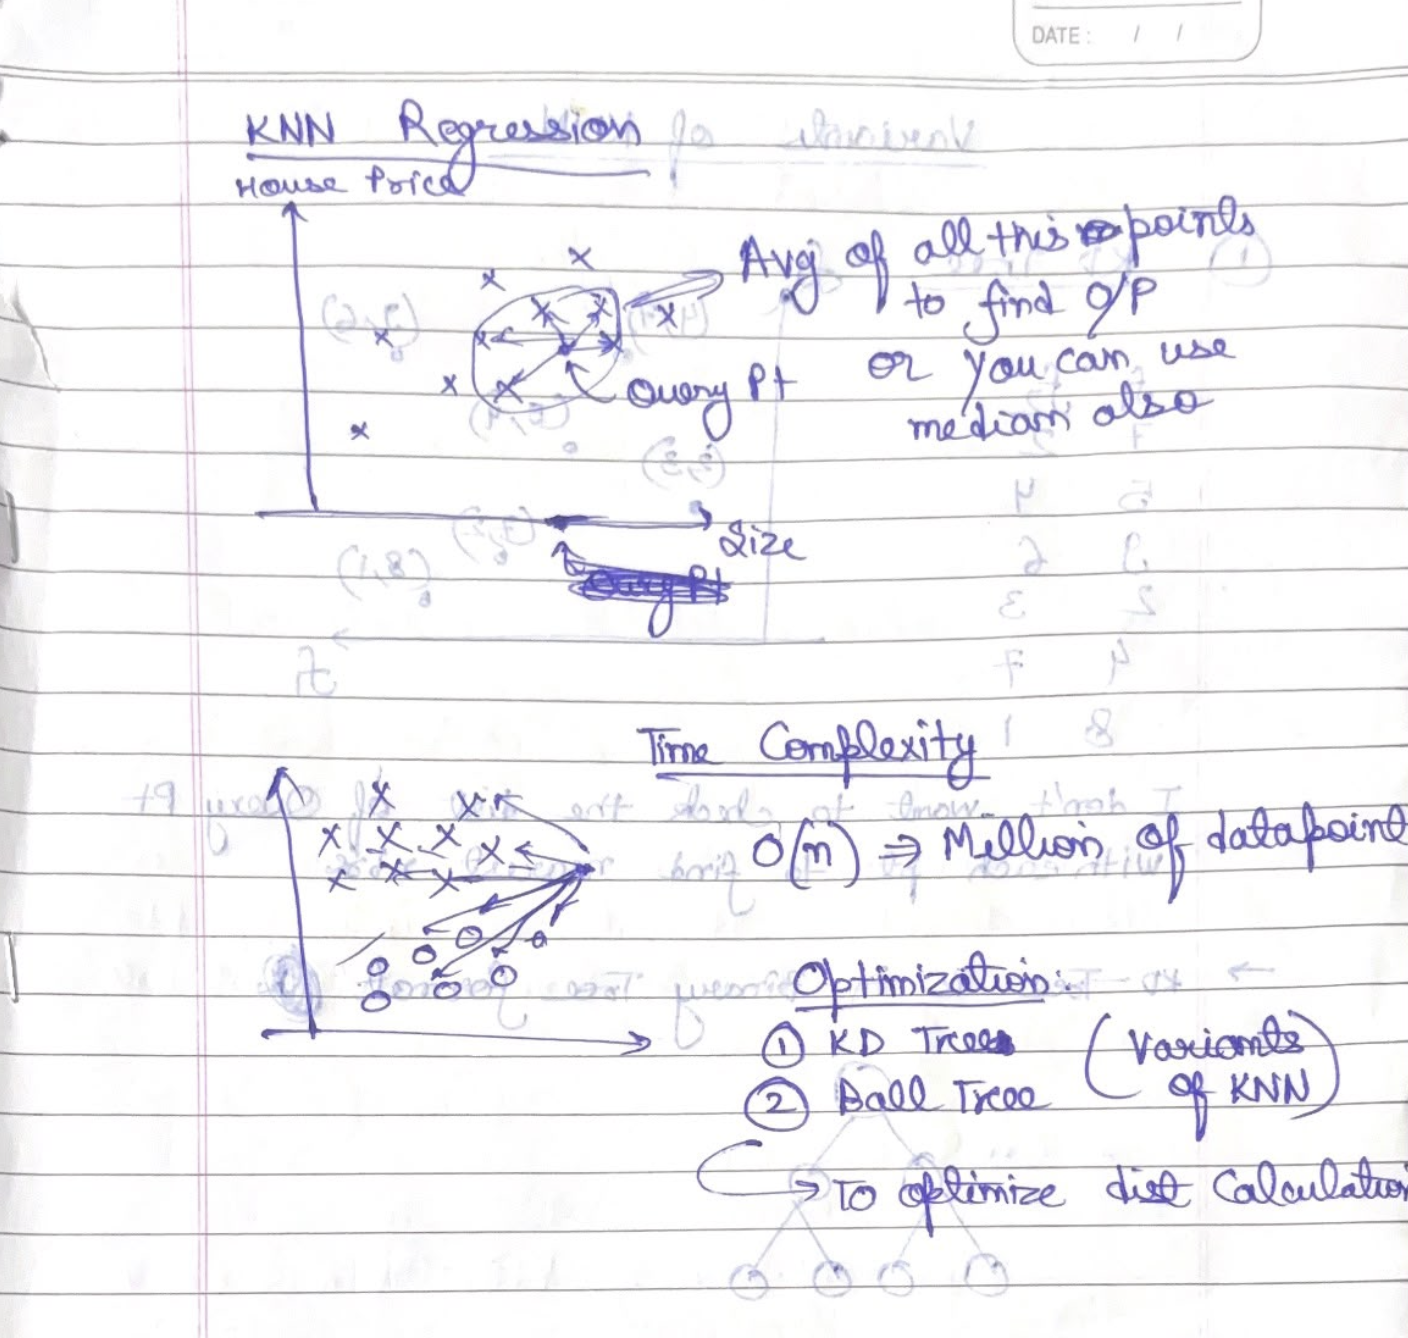

KD-Tree and Ball Tree are data structures commonly used to make KNN neighbor searches faster. In scikit-learn, you can use both with KNeighborsClassifier / KNeighborsRegressor.

## Why do we need KD-Tree and Ball Tree?

The basic KNN algorithm does this for every test point:

1. Calculate distance to every training point
2. Sort/find the nearest K
3. Use those neighbors for prediction

If you have:

- 1 million training points
- 100 features

doing this repeatedly becomes expensive.

So instead of comparing a point with every single point, we can organize the training data into a tree structure that allows us to quickly eliminate regions that cannot contain the nearest neighbors.

The two important structures are:

1. KD-Tree
2. Ball Tree

In [ ]:
# sklearn.neighbors
# │
# ├── KNeighborsClassifier
# │      │
# │      ├── KD-Tree
# │      ├── Ball Tree
# │      └── Brute Force
# │
# ├── KNeighborsRegressor
# │      │
# │      ├── KD-Tree
# │      ├── Ball Tree
# │      └── Brute Force
# │
# ├── KDTree
# │
# ├── BallTree
# │
# └── KernelDensity
#        │
#        └── KDE

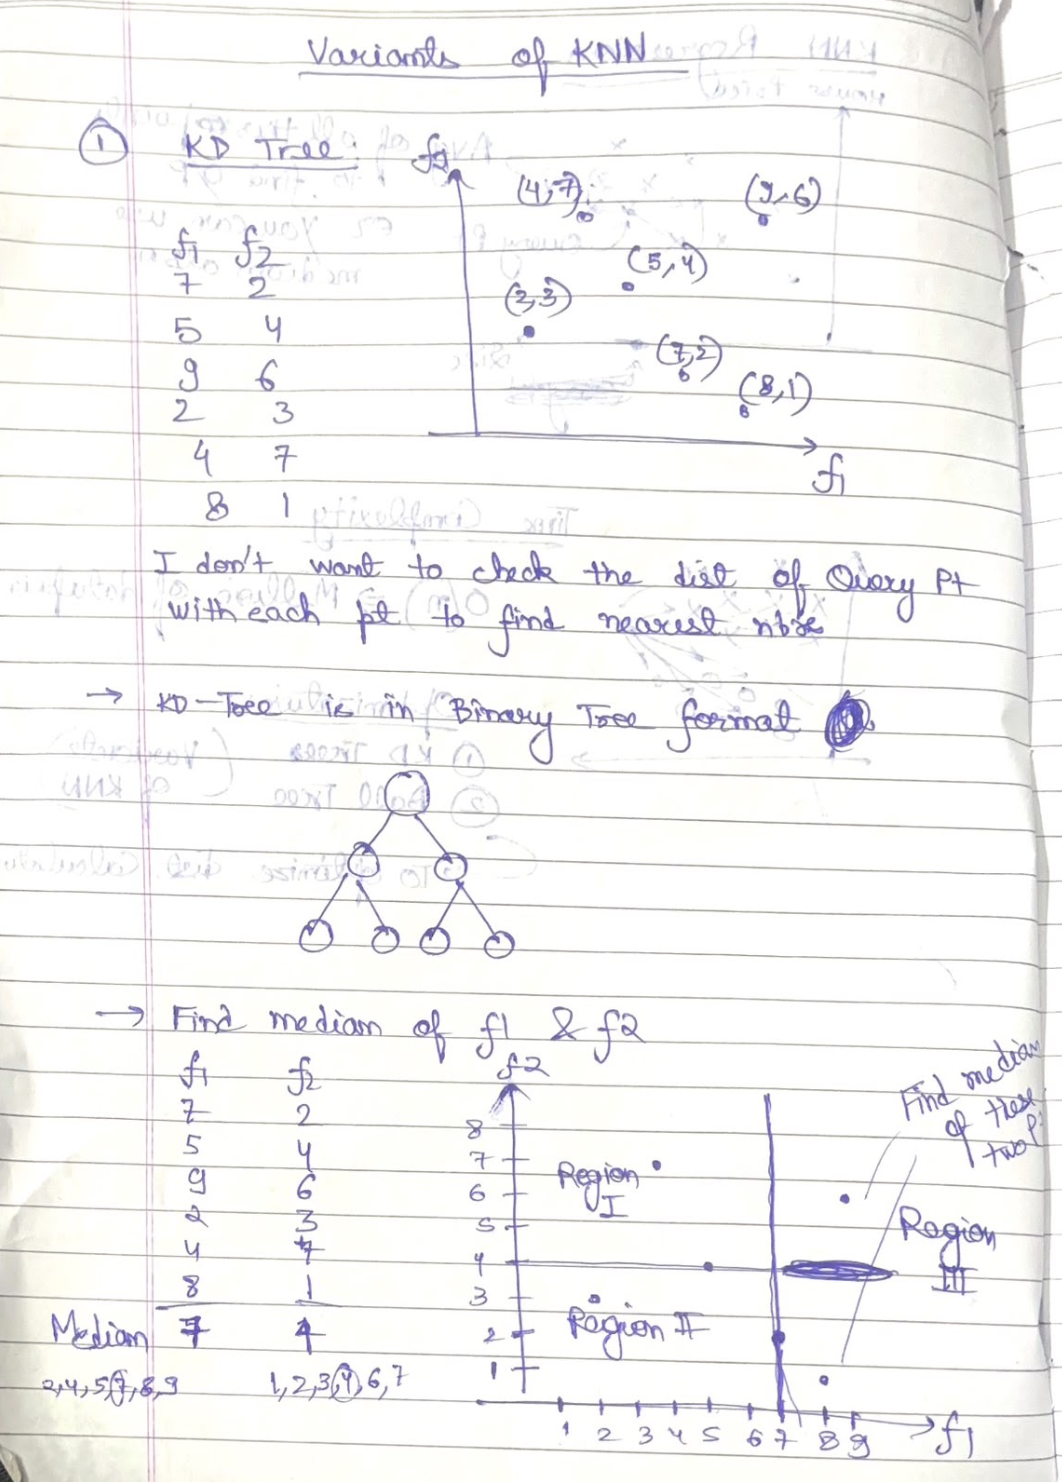

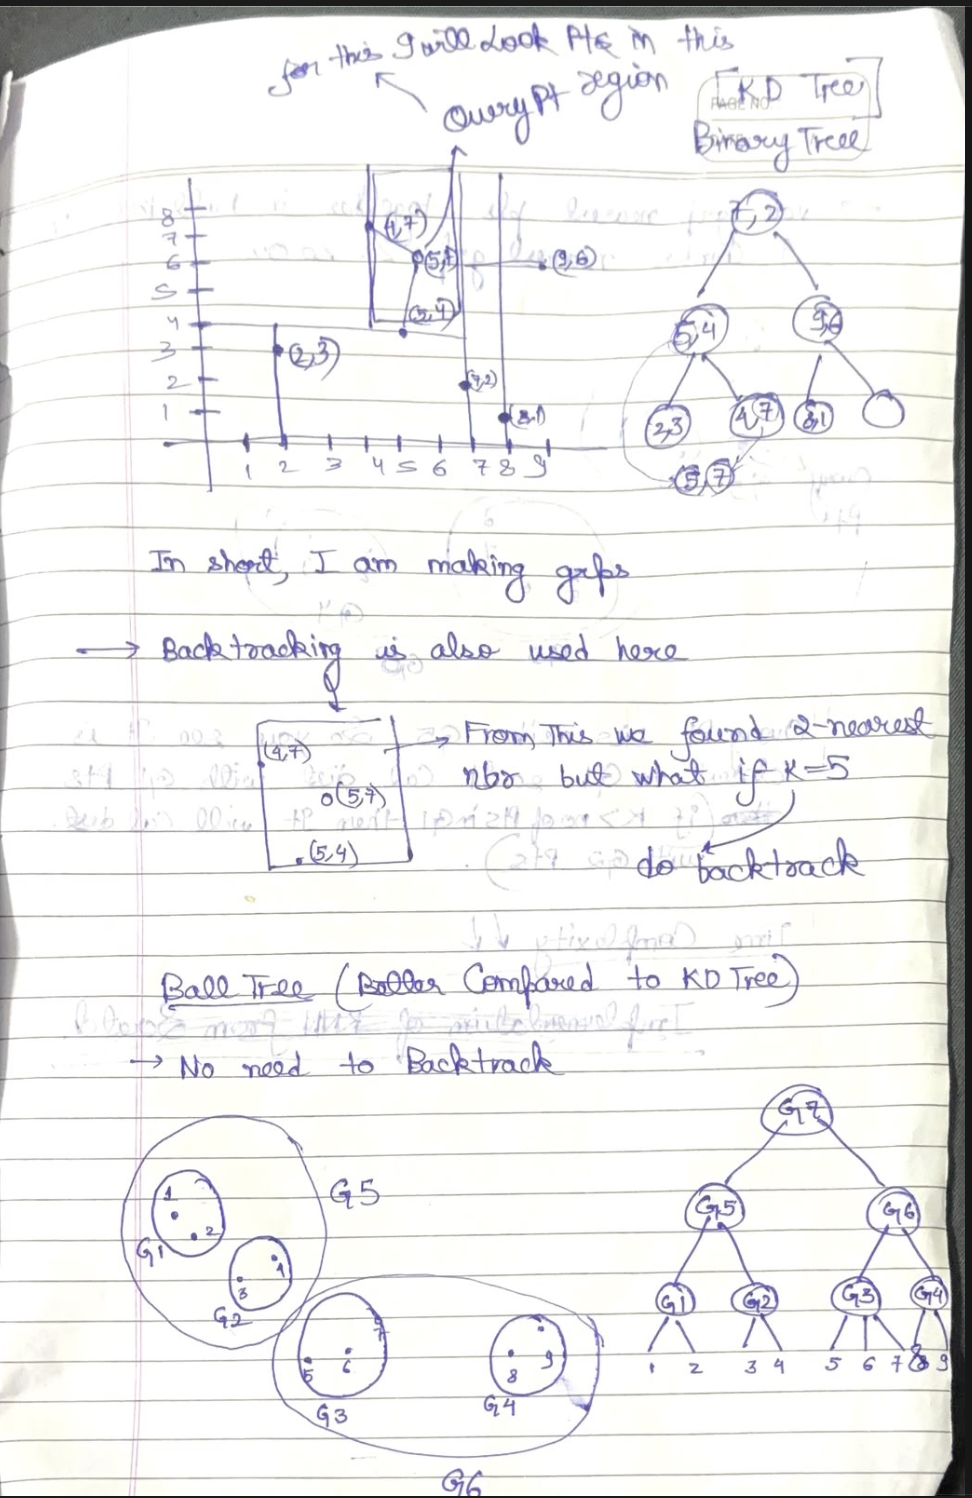

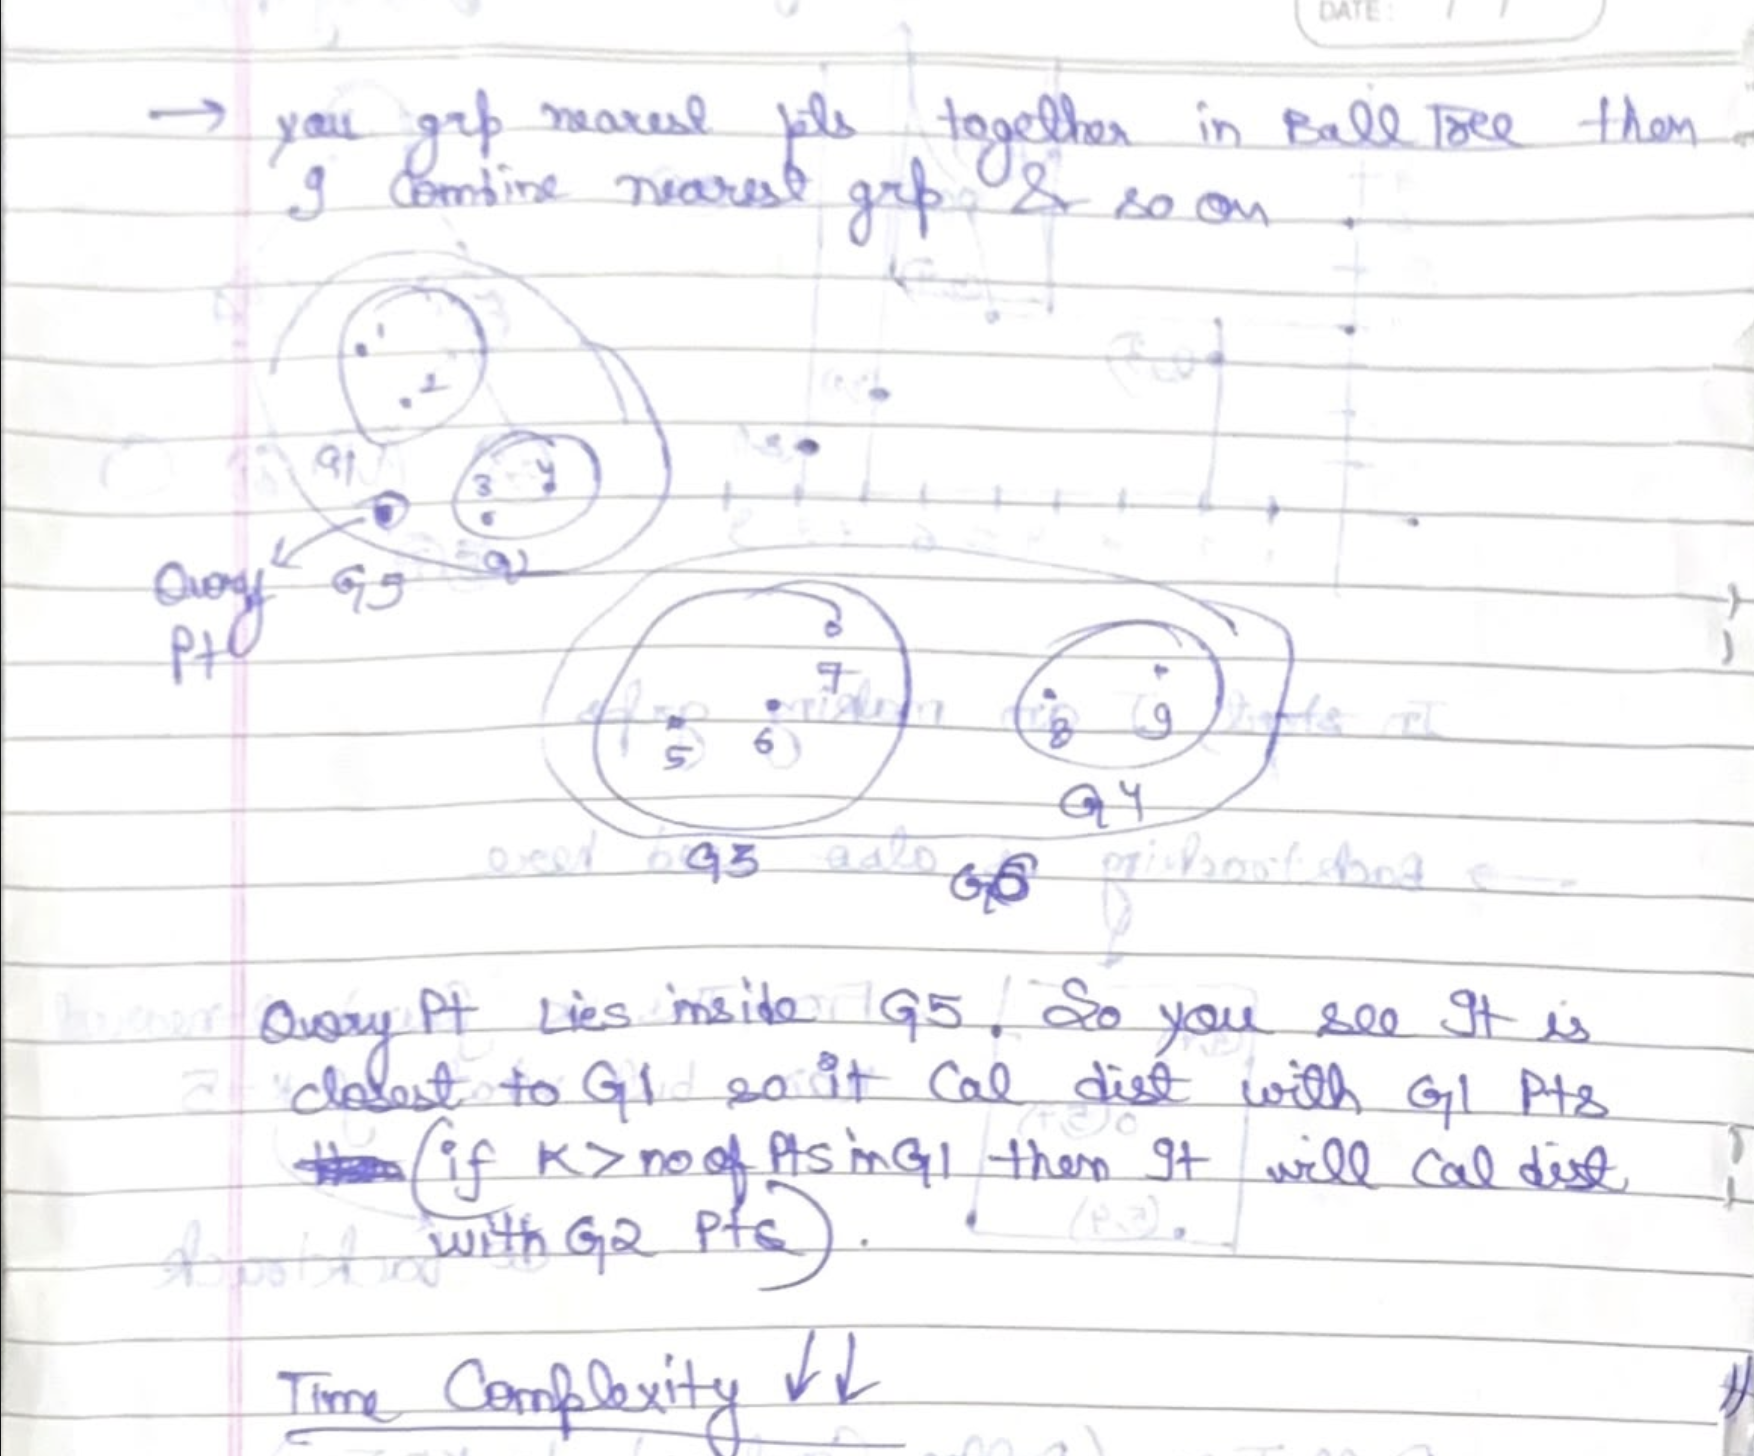

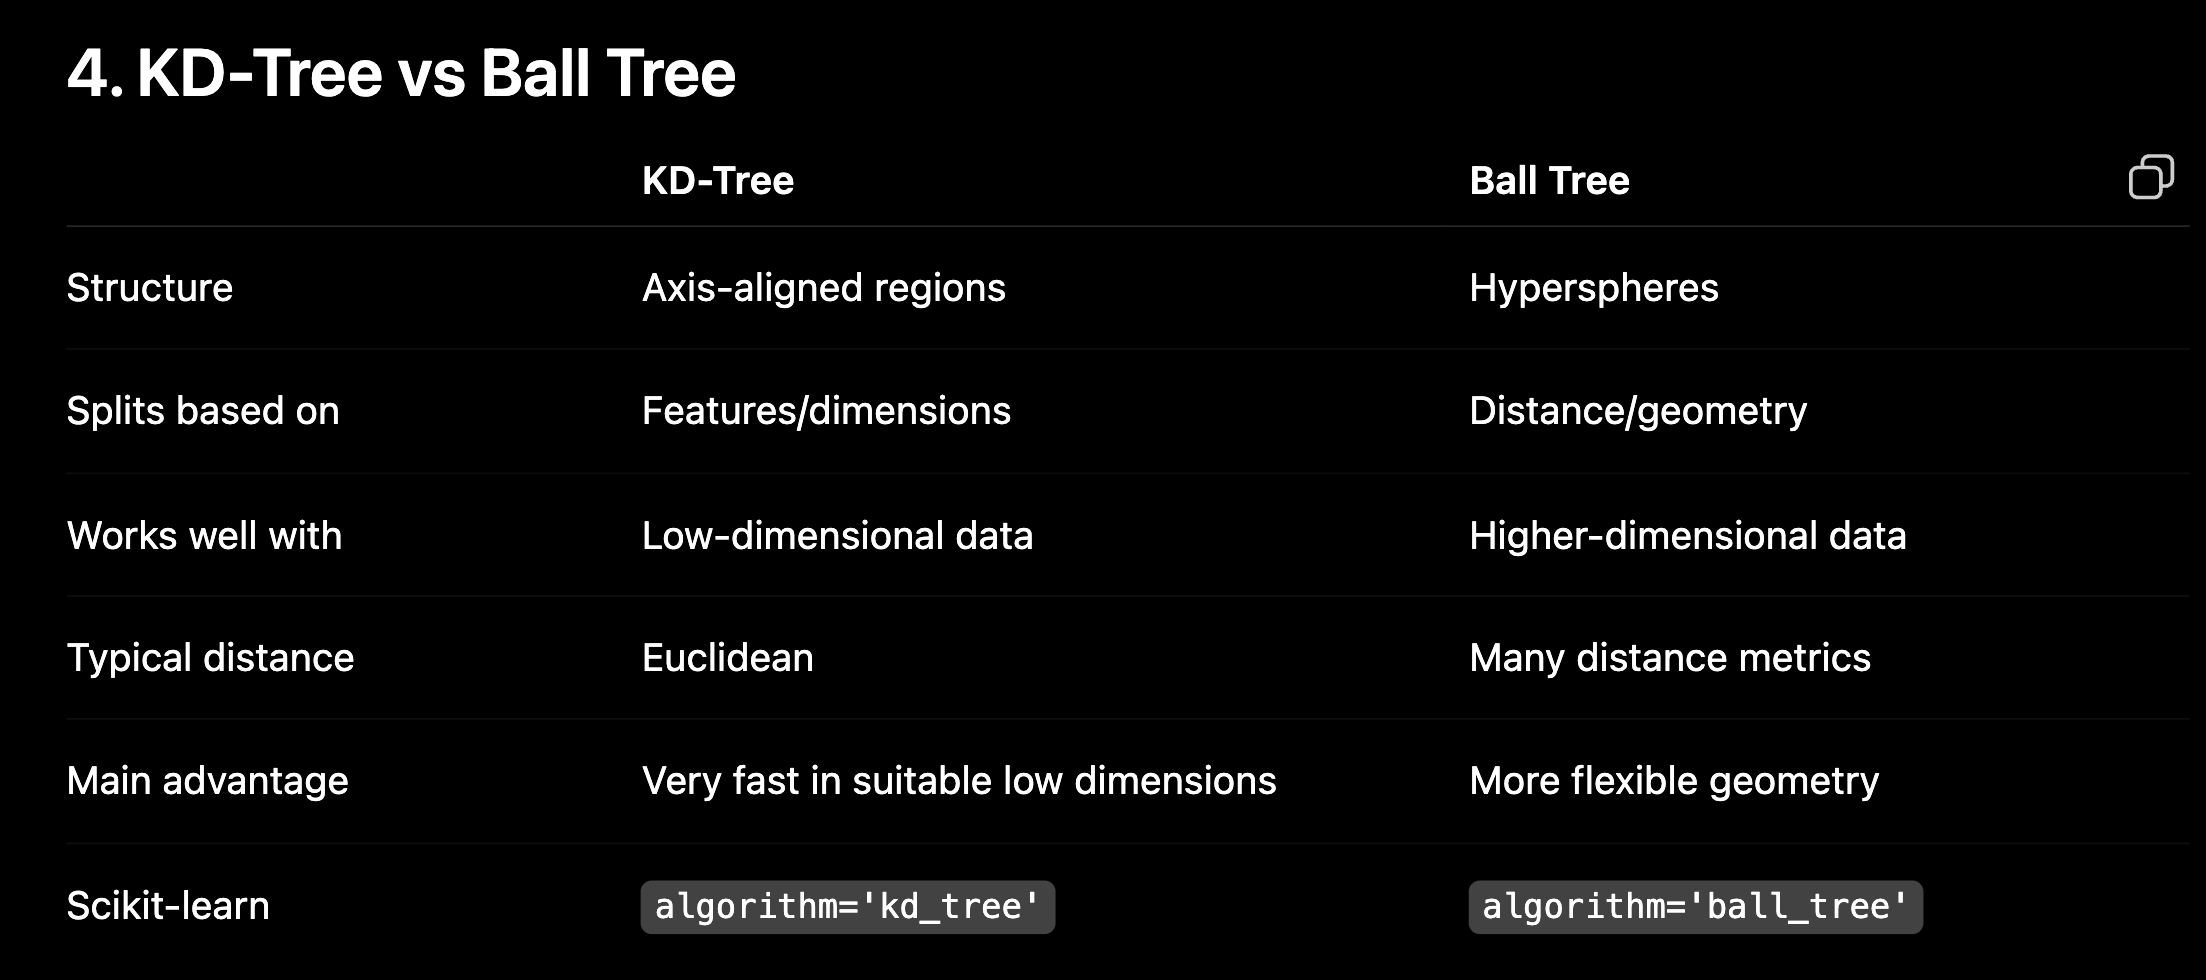

Neither tree changes the basic KNN prediction algorithm. They primarily change how neighbors are searched.

## Implement KNN using KD-Tree in sklearn

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Load data
X, y = load_iris(return_X_y=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model= Pipeline([ ('scaler',StandardScaler()),('knn',KNeighborsClassifier(algorithm='kd_tree',n_neighbors=5))])
# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


In [4]:
## algorithm = 'kd_tree' , 'auto' , 'ball_tree' , 'brute'


# brute

# Calculates distances directly between points.

# KNeighborsClassifier(
#     n_neighbors=5,
#     algorithm="brute"
# )

# Conceptually:

# Query
#  ↓
# Distance to every point
#  ↓
# Select K closest




# kd_tree
# KNeighborsClassifier(
#     n_neighbors=5,
#     algorithm="kd_tree"
# )

# Uses KD-Tree for neighbor search.



# ball_tree
# KNeighborsClassifier(
#     n_neighbors=5,
#     algorithm="ball_tree"
# )

# Uses Ball Tree.



# auto
# KNeighborsClassifier(
#     n_neighbors=5,
#     algorithm="auto"
# )

# Scikit-learn chooses an appropriate algorithm based on the data and other parameters.

In [3]:
# KNeighborsClassifier(
#     n_neighbors=5,
#     algorithm="kd_tree"
# )

# Use 5 nearest neighbors, and use a KD-Tree to find them.

## KD Tree directly

In [5]:
from sklearn.neighbors import KDTree
X, y = load_iris(return_X_y=True)
tree= KDTree(X)

print(tree)

In [6]:
distances, indices = tree.query(
    X[:1],
    k=5
)

print("Distances:", distances)
print("Indices:", indices)

Distances: [[0.         0.1        0.14142136 0.14142136 0.14142136]]
Indices: [[ 0 17  4 39 28]]


## Ball tree directly

In [ ]:
from sklearn.neighbors import BallTree
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

tree = BallTree(X)

distances, indices = tree.query(
    X[:1],
    k=5
)

print("Distances:", distances)
print("Indices:", indices)

## KDE (Kernel Density Estimation)

It is used to estimate the probability density of data.

For example, suppose you have:

In [ ]:
# Income
# 20k
# 25k
# 27k
# 30k
# 31k
# 35k
# 100k

KDE tries to estimate:

"Where is the data concentrated?"

Conceptually:



In [ ]:
# Density
#   ↑
#   |          /\
#   |        /    \
#   |      /        \          /\
#   |_____/__________\________/___\____→ Income

# It places a small kernel around each observation and combines them.

In [7]:
from sklearn.neighbors import KernelDensity
import numpy as np

X = np.array([
    [1],
    [2],
    [2.5],
    [3],
    [3.5],
    [4]
])

kde= KernelDensity(kernel='gaussian',bandwidth=0.5)

kde.fit(X)

,bandwidth,0.5
,algorithm,'auto'
,kernel,'gaussian'
,metric,'euclidean'
,atol,0
,rtol,0
,breadth_first,True
,leaf_size,40
,metric_params,None


In [8]:
X_test = np.array([
    [2],
    [10]
])

log_density = kde.score_samples(X_test)

print(log_density)

[ -1.38169082 -74.0175471 ]


## KNN Regressor

In [9]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error


In [ ]:
X, y = fetch_california_housing(
    return_X_y=True
)

print(X.shape)
print(y.shape)

# X → input features
# y → house prices

(20640, 8)
(20640,)


In [12]:
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


# ==========================
# 1. Load dataset
# ==========================

X, y = fetch_california_housing(
    return_X_y=True
)


# ==========================
# 2. Train-test split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ==========================
# 3. Feature scaling
# ==========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==========================
# 4. Create KNN Regressor
# ==========================

knn = KNeighborsRegressor(
    n_neighbors=5
)


# ==========================
# 5. Train
# ==========================

knn.fit(
    X_train,
    y_train
)


# ==========================
# 6. Prediction
# ==========================

y_pred = knn.predict(X_test)


# ==========================
# 7. Evaluation
# ==========================

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)


print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MSE : 0.4324216146043236
RMSE: 0.6575877238850522
R2  : 0.6700101862970989
